In [1]:
import os
import random
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve,
)

from imblearn.over_sampling import ADASYN

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.models import Sequential

import shap
from lime.lime_tabular import LimeTabularExplainer

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)


In [2]:
data = pd.read_csv("data.csv")

data.head()

,id,rpm,motor_power,torque,outlet_pressure_bar,air_flow,noise_db,outlet_temp,wpump_outlet_press,water_inlet_temp,...,gaccy,gaccz,haccx,haccy,haccz,bearings,wpump,radiator,exvalve,acmotor
0,1,499,1405.842858,27.511708,1.000,308.289879,40.840517,78.554715,2.960632,43.166392,...,0.383773,2.649801,1.213344,1.409218,2.962484,Ok,Ok,Clean,Clean,Stable
1,2,513,1457.370092,31.030115,1.081,307.833736,40.484226,76.902822,2.536711,47.342143,...,0.450954,2.669423,1.210674,1.379050,2.938135,Ok,Ok,Clean,Clean,Stable
2,3,495,1582.249959,33.484653,1.369,307.377593,40.918572,77.547021,2.112789,49.306593,...,0.443924,2.772009,1.210612,1.373490,2.991878,Ok,Ok,Clean,Clean,Stable
3,4,480,1712.466820,36.394475,1.691,306.975248,40.450953,80.059949,2.087534,46.886933,...,0.370457,2.876056,1.213223,1.443234,3.096158,Ok,Ok,Clean,Clean,Stable
4,5,498,1766.035170,38.249154,1.731,306.832132,41.233739,79.130424,2.338877,50.498100,...,0.383868,2.849451,1.209216,1.405190,3.059417,Ok,Ok,Clean,Clean,Stable


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   1000 non-null   int64  
 1   rpm                  1000 non-null   int64  
 2   motor_power          1000 non-null   float64
 3   torque               1000 non-null   float64
 4   outlet_pressure_bar  1000 non-null   float64
 5   air_flow             1000 non-null   float64
 6   noise_db             1000 non-null   float64
 7   outlet_temp          1000 non-null   float64
 8   wpump_outlet_press   1000 non-null   float64
 9   water_inlet_temp     1000 non-null   float64
 10  water_outlet_temp    1000 non-null   float64
 11  wpump_power          1000 non-null   float64
 12  water_flow           1000 non-null   float64
 13  oilpump_power        1000 non-null   float64
 14  oil_tank_temp        1000 non-null   float64
 15  gaccx                1000 non-null   float64
 16  

In [4]:
data.describe()

,id,rpm,motor_power,torque,outlet_pressure_bar,air_flow,noise_db,outlet_temp,wpump_outlet_press,water_inlet_temp,...,wpump_power,water_flow,oilpump_power,oil_tank_temp,gaccx,gaccy,gaccz,haccx,haccy,haccz
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,1499.516000,6984.877371,49.186120,4.054049,754.673930,53.412121,118.855110,2.799610,83.021711,...,222.185445,53.708176,300.484123,46.237663,0.601789,0.349667,3.923073,1.101253,1.350042,3.495037
std,288.819436,707.681915,4269.277571,18.706750,1.862761,442.743491,8.055363,19.120181,0.455274,18.644992,...,3.774537,6.587259,0.408703,0.196139,0.058719,0.040667,1.610130,0.058546,0.040871,0.817667
min,1.000000,480.000000,1402.424603,13.222197,1.000000,95.098952,39.879017,76.902822,1.834533,43.166392,...,213.525207,38.570791,299.507859,45.806178,0.540045,0.274650,1.730301,1.039910,1.270696,2.329267
25%,250.750000,988.750000,3559.437042,33.749857,2.443750,305.388152,46.490976,104.731080,2.448208,68.914714,...,219.471768,50.459245,300.187873,46.090060,0.558092,0.316543,2.576739,1.057717,1.318785,2.802622
50%,500.500000,1500.000000,5906.662534,48.890905,4.038000,608.626411,52.708480,118.275842,2.780492,82.101660,...,221.889622,58.112667,300.470013,46.236213,0.576814,0.349343,3.610639,1.075392,1.348189,3.339698
75%,750.250000,2010.000000,9636.002782,63.672921,5.600250,1193.266273,60.158248,132.850790,3.092101,95.792346,...,224.721620,58.552897,300.774788,46.378237,0.615021,0.375261,5.081960,1.113696,1.375232,4.071874
max,1000.000000,2520.000000,19454.559080,93.540405,8.664000,1539.911634,74.401986,172.711382,4.295136,137.543531,...,235.342910,59.174992,301.435483,46.755690,0.726604,0.459811,9.209166,1.227134,1.461809,6.107852


In [5]:
label_maps = {
    "bearings": {"Ok": 0, "Noisy": 1},
    "wpump": {"Ok": 0, "Noisy": 1},
    "radiator": {"Clean": 0, "Dirty": 1},
    "exvalve": {"Clean": 0, "Dirty": 1},
}

data = data.copy()
for column, mapping in label_maps.items():
    data[column] = data[column].map(mapping)


In [6]:
target_column = "bearings"
label_columns = ["bearings", "wpump", "radiator", "exvalve", "acmotor"]
feature_columns = [column for column in data.columns if column not in label_columns + ["id"]]

X = data[feature_columns]
y = data[target_column]

print("Feature columns:", feature_columns)
print("Class distribution:")
print(y.value_counts().rename(index={0: "Ok", 1: "Noisy"}))


Feature columns: ['rpm', 'motor_power', 'torque', 'outlet_pressure_bar', 'air_flow', 'noise_db', 'outlet_temp', 'wpump_outlet_press', 'water_inlet_temp', 'water_outlet_temp', 'wpump_power', 'water_flow', 'oilpump_power', 'oil_tank_temp', 'gaccx', 'gaccy', 'gaccz', 'haccx', 'haccy', 'haccz']
Class distribution:
bearings
Ok       800
Noisy    200
Name: count, dtype: int64


In [7]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_train_raw,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=RANDOM_STATE,
)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train_raw)
X_val = scaler.transform(X_val_raw)
X_test = scaler.transform(X_test_raw)

print("Train:", y_train.value_counts().to_dict())
print("Validation:", y_val.value_counts().to_dict())
print("Test:", y_test.value_counts().to_dict())


Train: {0: 512, 1: 128}
Validation: {0: 128, 1: 32}
Test: {0: 160, 1: 40}


In [8]:
adasyn = ADASYN(random_state=RANDOM_STATE)
X_train_res, y_train_res = adasyn.fit_resample(X_train, y_train)

print("After ADASYN:")
print(pd.Series(y_train_res).value_counts().to_dict())


After ADASYN:
{1: 518, 0: 512}


In [9]:
model = Sequential([
    Input(shape=(X_train_res.shape[1],)),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(16, activation="relu", name="latent_features"),
    Dropout(0.3),
    Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_features (Dense)         │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,217 (4.75 KB)

 Trainable params: 1,217 (4.75 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
)

history = model.fit(
    X_train_res,
    y_train_res,
    epochs=150,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    shuffle=True,
    verbose=1,
)


Epoch 1/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5136 - loss: 0.6982 - val_accuracy: 0.5188 - val_loss: 0.6898
Epoch 2/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6019 - loss: 0.6780 - val_accuracy: 0.6000 - val_loss: 0.6758
Epoch 3/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6126 - loss: 0.6703 - val_accuracy: 0.6375 - val_loss: 0.6391
Epoch 4/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6340 - loss: 0.6525 - val_accuracy: 0.6687 - val_loss: 0.6243
Epoch 5/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6408 - loss: 0.6398 - val_accuracy: 0.6687 - val_loss: 0.6201
Epoch 6/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6592 - loss: 0.6225 - val_accuracy: 0.7000 - val_loss: 0.5893
Epoch 7/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6767 - loss: 0.6086 - val_accuracy: 0.7188 - val_loss: 0.5650
Epoch 8/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7068 - loss: 0.5842 - val_accuracy: 0.7500 - 

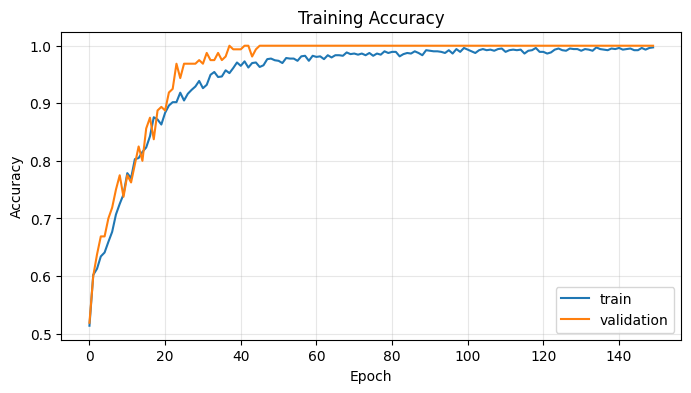

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["train", "validation"])
plt.grid(alpha=0.3)
plt.show()


In [12]:
feature_extractor = tf.keras.Model(
    inputs=model.inputs,
    outputs=model.get_layer("latent_features").output,
)

train_features_res = feature_extractor.predict(X_train_res)
val_features = feature_extractor.predict(X_val)
test_features = feature_extractor.predict(X_test)

print("Latent train shape:", train_features_res.shape)
print("Latent validation shape:", val_features.shape)
print("Latent test shape:", test_features.shape)


33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Latent train shape: (1030, 16)
Latent validation shape: (160, 16)
Latent test shape: (200, 16)


In [13]:
svm = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    class_weight="balanced",
    probability=True,
    random_state=RANDOM_STATE,
)

svm.fit(train_features_res, y_train_res)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [14]:
pred = svm.predict(test_features)
y_prob = svm.predict_proba(test_features)[:, 1]

metrics = {
    "accuracy": accuracy_score(y_test, pred),
    "balanced_accuracy": balanced_accuracy_score(y_test, pred),
    "f1_fault_noisy": f1_score(y_test, pred),
    "roc_auc": roc_auc_score(y_test, y_prob),
}

for name, value in metrics.items():
    print(f"{name}: {value:.4f}")

print(classification_report(
    y_test,
    pred,
    target_names=["Ok", "Noisy"],
))


accuracy: 0.9950
balanced_accuracy: 0.9875
f1_fault_noisy: 0.9873
roc_auc: 1.0000
              precision    recall  f1-score   support

          Ok       0.99      1.00      1.00       160
       Noisy       1.00      0.97      0.99        40

    accuracy                           0.99       200
   macro avg       1.00      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200



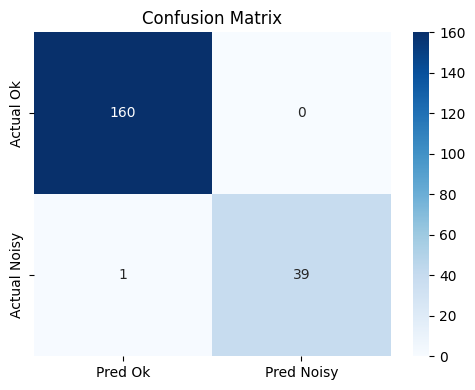

In [15]:
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred Ok", "Pred Noisy"],
    yticklabels=["Actual Ok", "Actual Noisy"],
)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


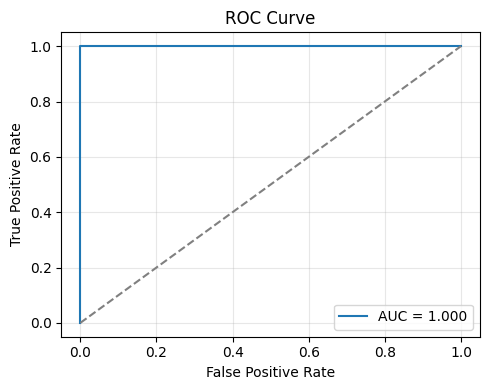

In [16]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f"AUC = {metrics['roc_auc']:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


  0%|          | 0/100 [00:00<?, ?it/s]

C:\Users\123vi\AppData\Local\Temp\ipykernel_12836\2849116730.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


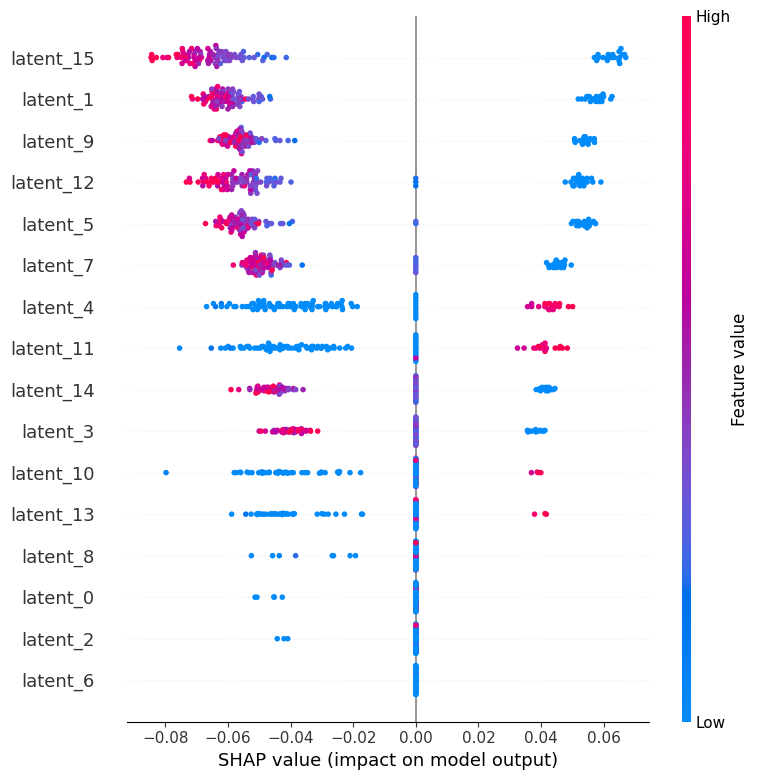

In [17]:
latent_feature_names = [f"latent_{i}" for i in range(train_features_res.shape[1])]

explainer = shap.KernelExplainer(
    svm.predict,
    shap.sample(train_features_res, 100, random_state=RANDOM_STATE),
)

shap_values = explainer.shap_values(test_features[:100])
shap.summary_plot(
    shap_values,
    test_features[:100],
    feature_names=latent_feature_names,
)


In [18]:
lime_explainer = LimeTabularExplainer(
    train_features_res,
    feature_names=latent_feature_names,
    class_names=["Ok", "Noisy"],
    mode="classification",
    discretize_continuous=True,
    random_state=RANDOM_STATE,
)

lime_explanation = lime_explainer.explain_instance(
    test_features[0],
    svm.predict_proba,
    num_features=8,
)

lime_explanation.show_in_notebook(show_table=True)


ImportError: cannot import name 'display' from 'IPython.core.display' (d:\TugasAkhir\cmms-manufacture-main - Copy\machine-learning filtered data\env\Lib\site-packages\IPython\core\display.py)

In [ ]:
models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

model.save(models_dir / "dnn_classifier.keras")
feature_extractor.save(models_dir / "dnn_feature_extractor.keras")

joblib.dump(
    {
        "scaler": scaler,
        "svm": svm,
        "feature_columns": feature_columns,
        "target_column": target_column,
        "label_mapping": label_maps[target_column],
        "metrics": metrics,
    },
    models_dir / "hybrid_model.pkl",
)

print("Saved model artifacts to", models_dir.resolve())


In [ ]:
# Conclusion
#
# Pipeline sudah diperbaiki:
# 1. Kolom id tidak dipakai sebagai fitur.
# 2. Fitur dipilih eksplisit sehingga haccz ikut digunakan.
# 3. Split train/validation/test dibuat stratified dan reproducible.
# 4. Scaler hanya fit pada data train untuk mencegah data leakage.
# 5. ADASYN hanya diterapkan pada data train.
# 6. Validation menggunakan data asli yang stratified, bukan validation_split dari ekor data ADASYN.
# 7. Evaluasi memakai accuracy, balanced accuracy, F1 fault, ROC-AUC, classification report, dan confusion matrix.
